In [10]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import adrienParamClassSheared as params
import adrienUtils as utils

# Force refresh if needed
importlib.reload(params)
importlib.reload(utils)
utils.memory_report(globals(), min_gb=0.1)

(No NumPy arrays above threshold)

Notebook memory used     :   0.59 GB (  0.5 %)
Remaining available to me: 127.41 GB ( 99.5 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [7]:
# Load in simulation parameters from the parameter list
pList = params.generate()
p = pList["R4P7"]
x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)
(p.Nx,p.Ny,p.Nz) 

(5120, 2560, 1280)

In [8]:
# Lazy loading test
fields = utils.open_lazy_fields(["u", "v", "w", "r", "ee", "chi"], p)

# Define basic parameters
Nx = p.Nx; Ny=p.Ny; Nz=p.Nz;
#Ek = p.targKE
N2 = -p.dGrad*p.zAccel
Ri = N2
N = np.sqrt(N2)
p.N = N; p.N2 = N2; p.Ri = Ri;
nu = p.kinV

# Compute approximate averages with stride to reduce I/O 
# THIS DOES TAKE UP RAM... IN THE FUTURE HOPEFULLY I CAN GET STEVE'S AVERAGES DIRECTLY
stride = (50, 50, 50)
Ep = utils.mean3d_strided_power(fields["r"], power=2, stride=stride)*(p.zAccel**2)/(2*N2)
Ek = (utils.mean3d_strided_power(fields["u"], power=2, stride=stride)+utils.mean3d_strided_power(fields["v"], power=2, stride=stride)+utils.mean3d_strided_power(fields["w"], power=2, stride=stride))/2
Ek_pct = Ek/p.targKE*100
eps_avg = utils.mean3d_strided(fields["ee"], stride=stride)
chi_avg = utils.mean3d_strided(fields["chi"], stride=stride)
RPK = Ep/Ek
Reb = eps_avg / (nu*N2)
Gamma = chi_avg/eps_avg 

# Print key values
print(f"<ε> = {eps_avg:.2e}")
print(f"<χ> = {chi_avg:.2e}")
print(f"Ri = {Ri:.3f}")
print(f"Reb = {Reb:.1f}")
print(f"Γ = {Gamma:.3f}")
print(f"Measured Ek = {Ek:.3e} ({Ek_pct:.2f}% of target)")
print(f"Measured Ep = {Ep:.3e}")
print(f"RPK = {RPK:.2f}")
utils.memory_report(globals(), min_gb=0.1)

<ε> = 3.28e-03
<χ> = 5.33e-04
Ri = 0.153
Reb = 85.6
Γ = 0.163
Measured Ek = 1.558e-02 (98.65% of target)
Measured Ep = 2.776e-03
RPK = 0.18
(No NumPy arrays above threshold)

Notebook memory used     :   0.59 GB (  0.5 %)
Remaining available to me: 127.41 GB ( 99.5 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [ ]:
# NEW
stride = (1,1,1)
iy = Ny // 2
iz = Nz // 2
ix = Nx // 2

stats = dict(Ek=Ek, Ep=Ep, eps_avg=eps_avg, chi_avg=chi_avg)
# s = utils.get_derived_slices_multi(
#     fields, p, stats,
#     planes=["xz","xy","yz"],
#     idx={"xz": p.Ny//2, "xy": p.Nz//2, "yz": p.Nx//2},
#     stride=stride
# )

s = utils.get_derived_slices_multi(
    fields, p, stats,
    planes=["xz","xy","yz"],
    idx={"xz": p.Ny//2, "xy": p.Nz//2, "yz": p.Nx//2},
    stride=stride,
    verbose=True
)

[get_derived_slices_multi] plane 1/3 'xz' idx=1280 stride=(1, 1, 1)
  reading: u,v,w,r,ee,chi ...
  computing derived fields ...
  done plane 'xz'
[get_derived_slices_multi] plane 2/3 'xy' idx=640 stride=(1, 1, 1)
  reading: u,v,w,r,ee,chi ...
  computing derived fields ...
  done plane 'xy'
[get_derived_slices_multi] plane 3/3 'yz' idx=2560 stride=(1, 1, 1)
  reading: u,v,w,r,ee,chi ...
  computing derived fields ...


In [ ]:
print("planes:", s.available_planes())
print("vars:", s.available_vars())
print("uN xy shape:", s.uN.xy.shape)
print("uN xz shape:", s.uN.xz.shape)
print("uN yz shape:", s.uN.yz.shape)

total = 0
for vname, vs in s.vars.items():
    for pl in vs.available():
        a = getattr(vs, pl)
        total += a.nbytes
        print(vname, pl, a.shape, a.dtype, f"{a.nbytes/1024**2:.1f} MB")
print("TOTAL in s:", f"{total/1024**3:.3f} GB")

# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.01)

uN xz (3072, 768) float32 9.0 MB
uN xy (3072, 1536) float32 18.0 MB
uN yz (1536, 768) float32 4.5 MB
vN xz (3072, 768) float32 9.0 MB
vN xy (3072, 1536) float32 18.0 MB
vN yz (1536, 768) float32 4.5 MB
wN xz (3072, 768) float32 9.0 MB
wN xy (3072, 1536) float32 18.0 MB
wN yz (1536, 768) float32 4.5 MB
bN xz (3072, 768) float32 9.0 MB
bN xy (3072, 1536) float32 18.0 MB
bN yz (1536, 768) float32 4.5 MB
epslog xz (3072, 768) float32 9.0 MB
epslog xy (3072, 1536) float32 18.0 MB
epslog yz (1536, 768) float32 4.5 MB
chilog xz (3072, 768) float32 9.0 MB
chilog xy (3072, 1536) float32 18.0 MB
chilog yz (1536, 768) float32 4.5 MB
TOTAL in s: 0.185 GB


Saved -> figures/R1P7_all_variables_y768_20260131_145044.png
Saved -> figures/R1P7_all_variables_z384_20260131_145048.png
Saved -> figures/R1P7_all_variables_x1536_20260131_145054.png


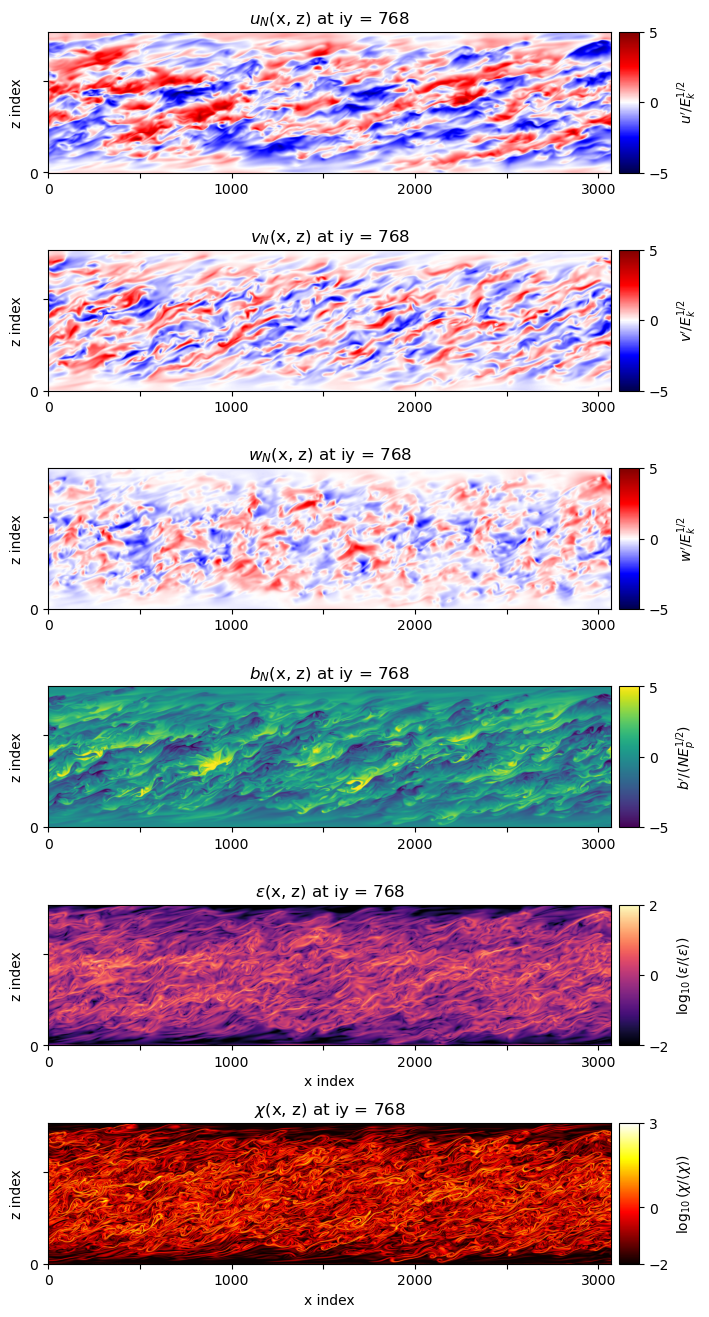

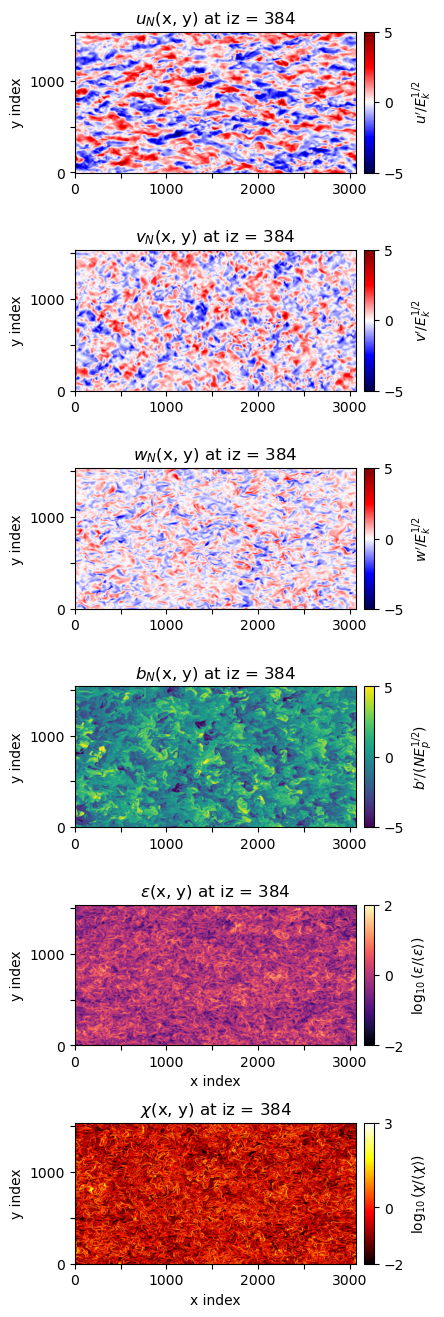

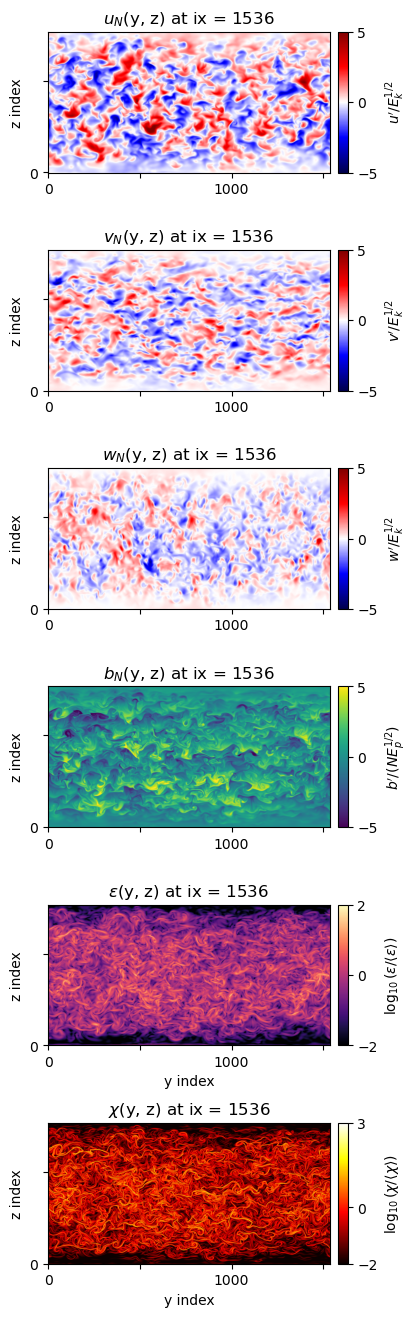

In [23]:
figs = utils.plot_slices_derived_bundle_multi(
    p, s,
    planes=("xz","xy","yz"),
    save=True, outdir="figures", fmt="png", dpi=300
)

In [24]:
import importlib, adrienUtils as utils
importlib.reload(utils)

# stride controls resolution of output (1,1,1 = full res)
stride = (2,2,2)

paths = utils.export_native_resolution_from_bundle_multi(
    p, s,
    planes=("xz","xy","yz"),
    outdir="figures"
)
paths

{'xz': {'u': 'figures/R1P7_u_native_res_y768_20260131_145950.png',
  'v': 'figures/R1P7_v_native_res_y768_20260131_145950.png',
  'w': 'figures/R1P7_w_native_res_y768_20260131_145950.png',
  'b': 'figures/R1P7_b_native_res_y768_20260131_145950.png',
  'e': 'figures/R1P7_e_native_res_y768_20260131_145950.png',
  'c': 'figures/R1P7_c_native_res_y768_20260131_145950.png'},
 'xy': {'u': 'figures/R1P7_u_native_res_z384_20260131_145954.png',
  'v': 'figures/R1P7_v_native_res_z384_20260131_145954.png',
  'w': 'figures/R1P7_w_native_res_z384_20260131_145954.png',
  'b': 'figures/R1P7_b_native_res_z384_20260131_145954.png',
  'e': 'figures/R1P7_e_native_res_z384_20260131_145954.png',
  'c': 'figures/R1P7_c_native_res_z384_20260131_145954.png'},
 'yz': {'u': 'figures/R1P7_u_native_res_x1536_20260131_150004.png',
  'v': 'figures/R1P7_v_native_res_x1536_20260131_150004.png',
  'w': 'figures/R1P7_w_native_res_x1536_20260131_150004.png',
  'b': 'figures/R1P7_b_native_res_x1536_20260131_150004.png',
